✅ All Libraries Imported Successfully
✅ Dataset Loaded
   Shape : 16719 rows × 16 columns
📋 DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  objec

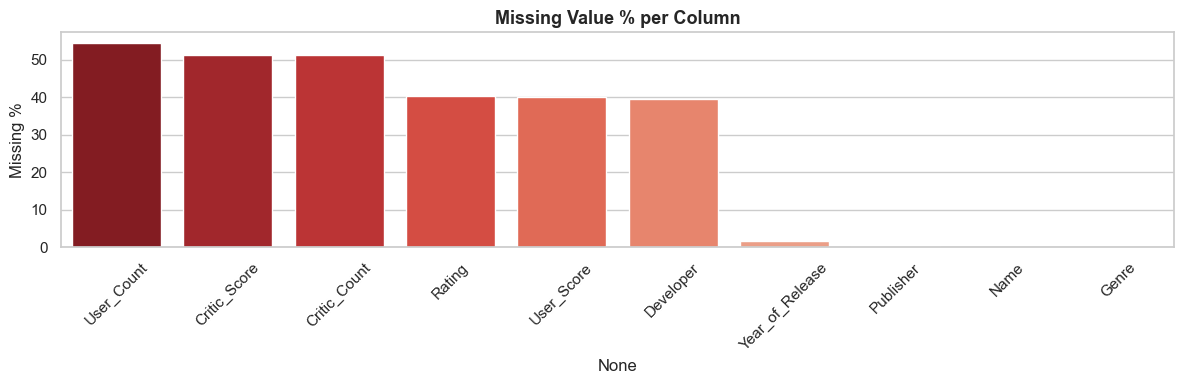

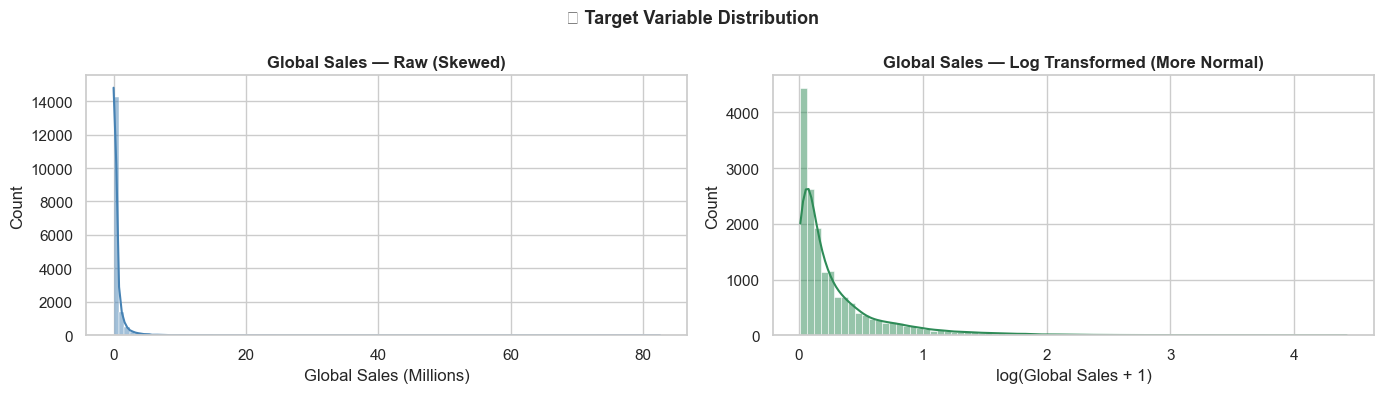


📌 Skewness (Raw): 17.378
📌 Skewness (Log): 2.761
   → Log-transform is JUSTIFIED because skewness > 1
🗑️  Dropped 0 rows with missing Global_Sales
   Remaining rows: 16719

✅ User_Score: 'tbd' replaced with NaN and converted to float
✅ Year_of_Release cleaned | Invalid years removed: 0
   Valid range: 1980 – 2020

✅ Outlier Removal | Upper bound = 1.70M
   Removed 1050 outlier rows | Remaining: 15669

📥 Filling Missing Numeric Values with Median:
   ✅ Critic_Score → median = 70.0
   ✅ Critic_Count → median = 20.0
   ✅ User_Score → median = 7.4
   ✅ User_Count → median = 21.0
   ✅ Year_of_Release → median = 2007.0

📥 Filling Missing Categorical Values with 'Unknown':
   ✅ Genre → 'Unknown'
   ✅ Publisher → 'Unknown'
   ✅ Developer → 'Unknown'
   ✅ Rating → 'Unknown'
   ✅ Platform → 'Unknown'

✅ Total Remaining Missing Values: 1
✅ Clean Dataset Shape: (15669, 16)


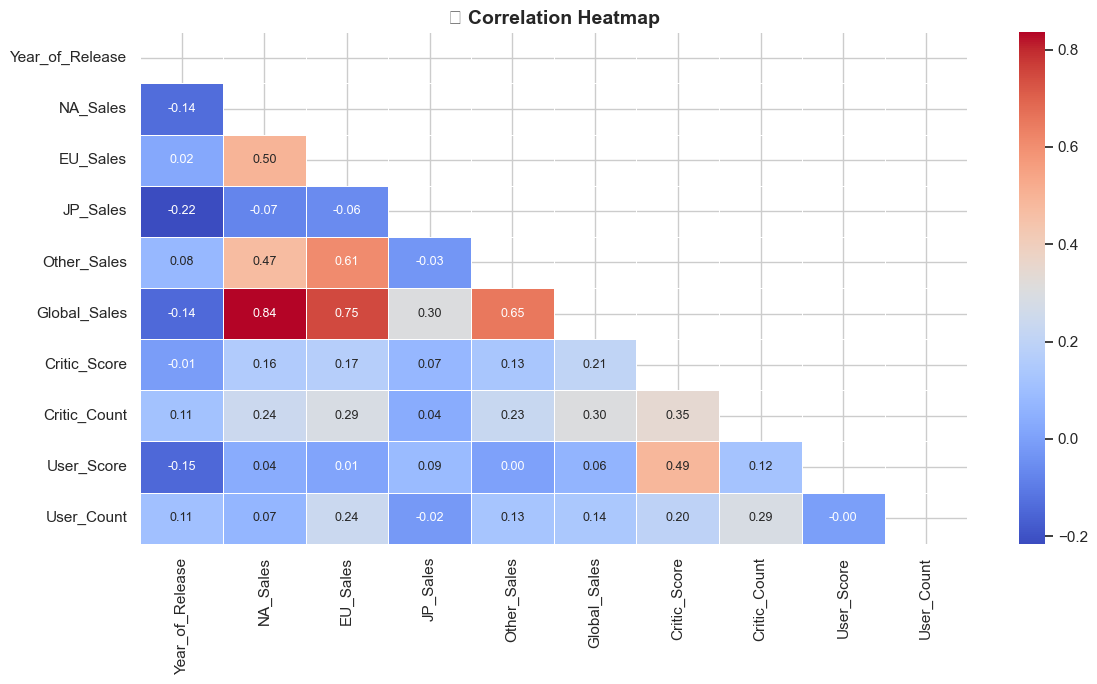


💡 Key Observations:
   - NA_Sales, EU_Sales have strong positive correlation with Global_Sales
   - Critic_Score has moderate correlation with Global_Sales
   - These regional sales will be DROPPED later to avoid data leakage


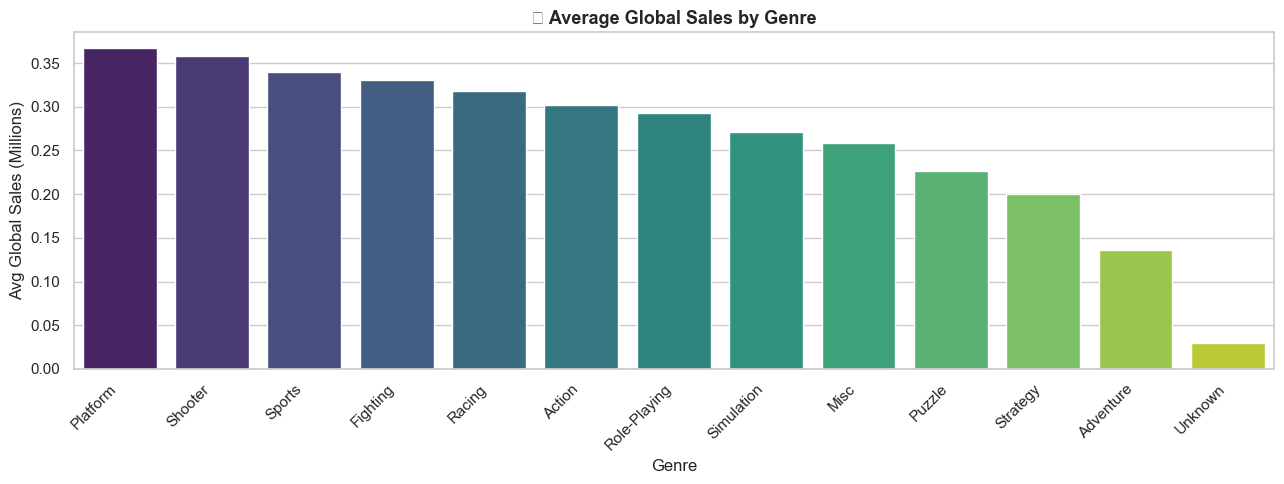

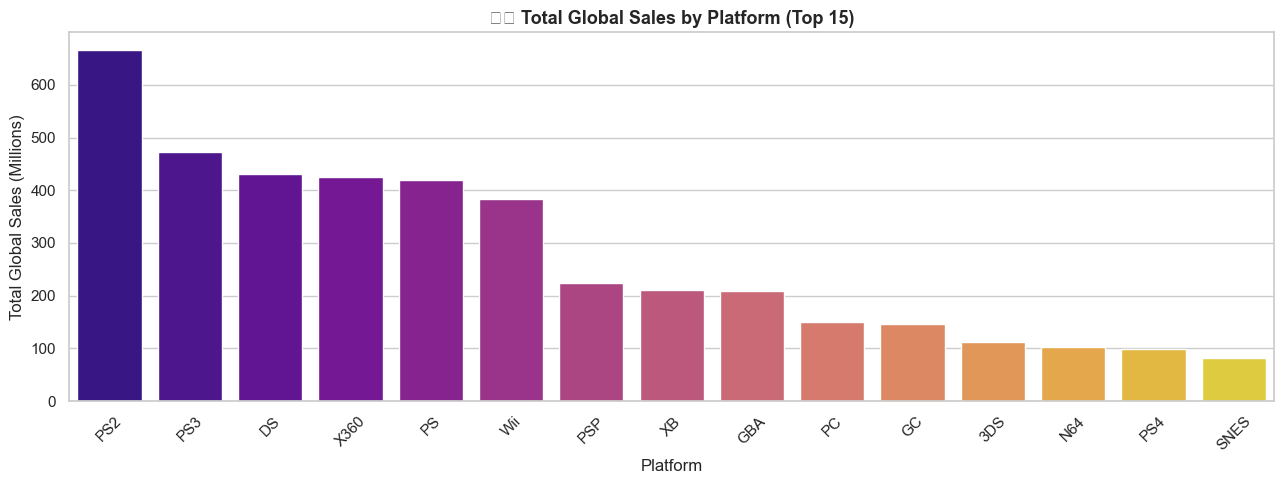

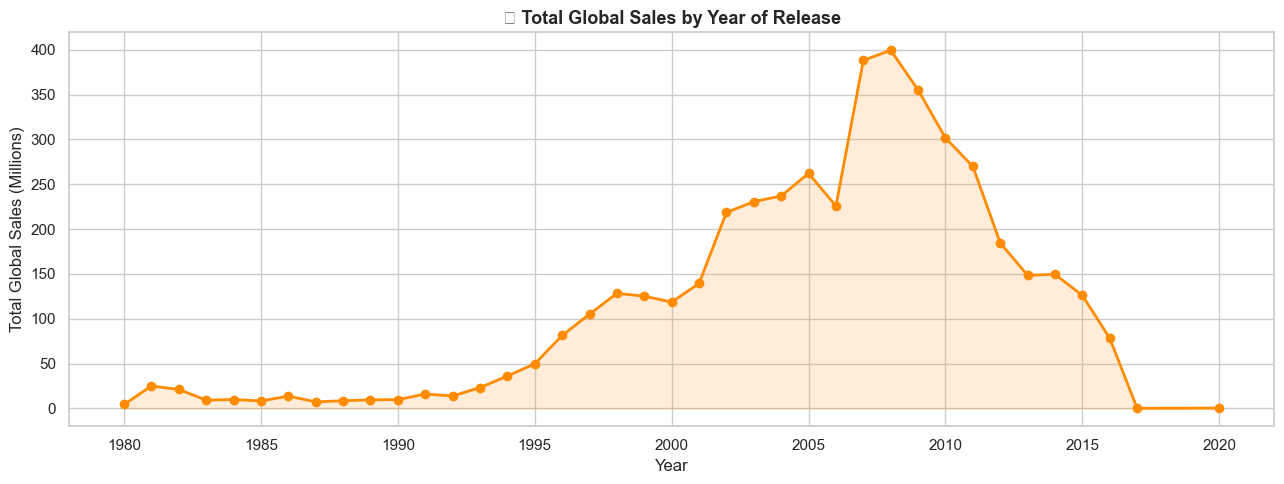

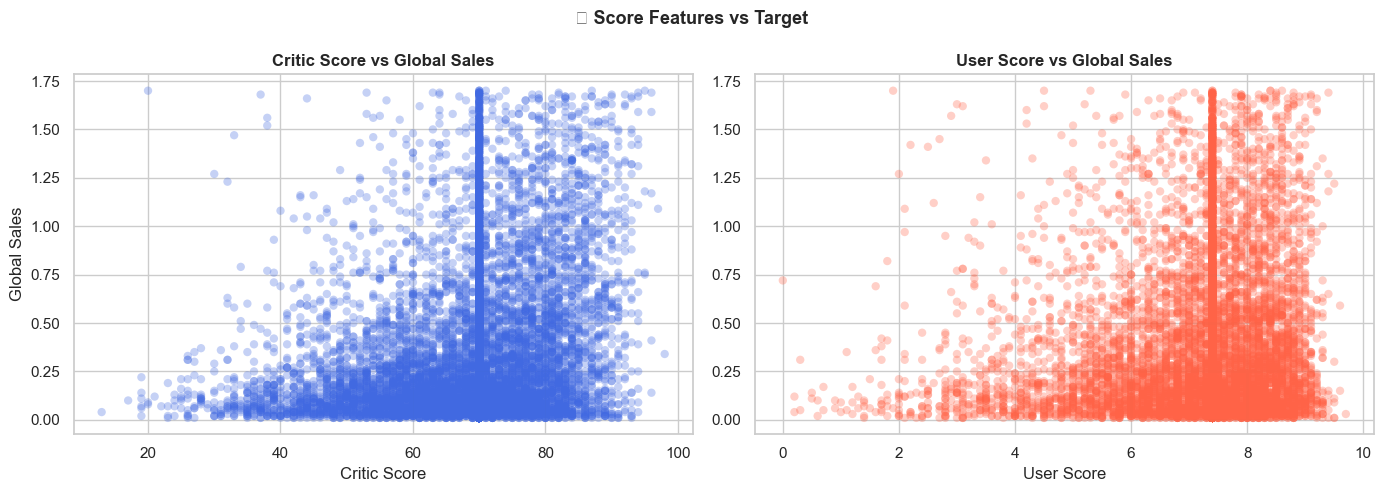

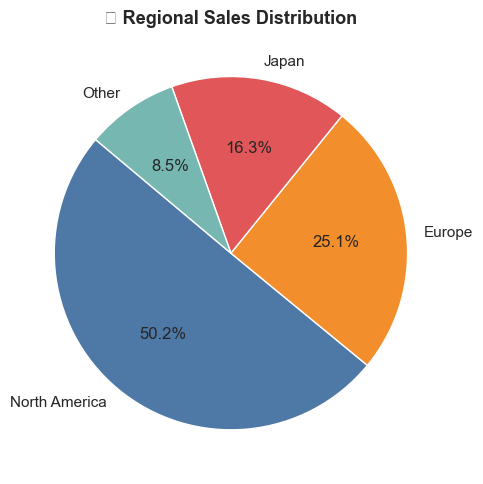

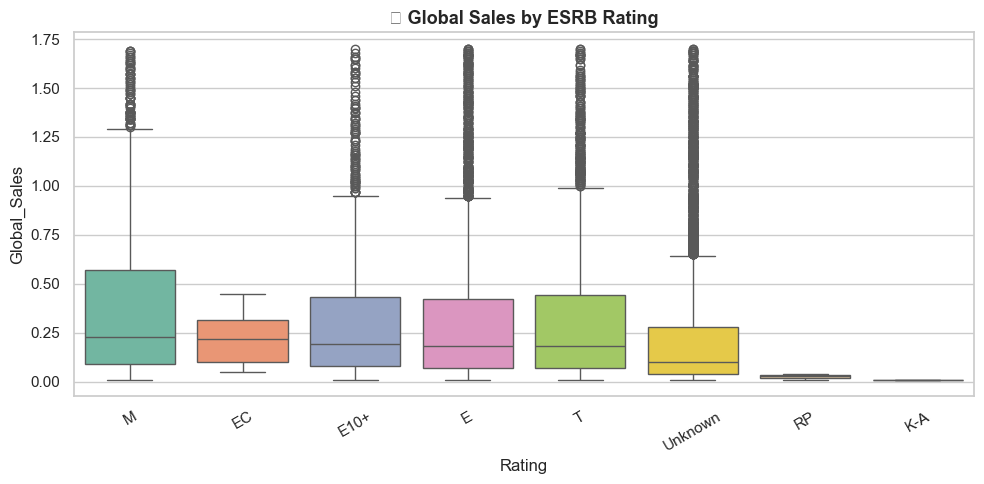

🗑️  Dropped columns to prevent data leakage: ['Name', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

✅ Features (X) shape : (15669, 10)
✅ Target  (y) shape  : (15669,)
📋 Feature Columns    : ['Platform', 'Year_of_Release', 'Genre', 'Publisher', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating']

✅ Train Set : 12535 rows
✅ Test  Set : 3134 rows
   NOTE: All preprocessing will be fit ONLY on X_train to avoid data leakage

════════════════════════════════════════════════════════════
  STEP 5 — DATA PREPROCESSING
════════════════════════════════════════════════════════════

📐 5A: Feature Engineering
   ✅ Avg_Score     → average of Critic + User score (0–10 scale)
   ✅ Review_Volume → log(Critic_Count + User_Count) — measures popularity
   ✅ Game_Age      → 2024 - Year_of_Release — how old the game is

🔤 5B: Frequency Encoding — Publisher & Developer
   (Too many unique values for Label Encoding → use frequency instead)
   ✅ Publisher → Frequency Encoded

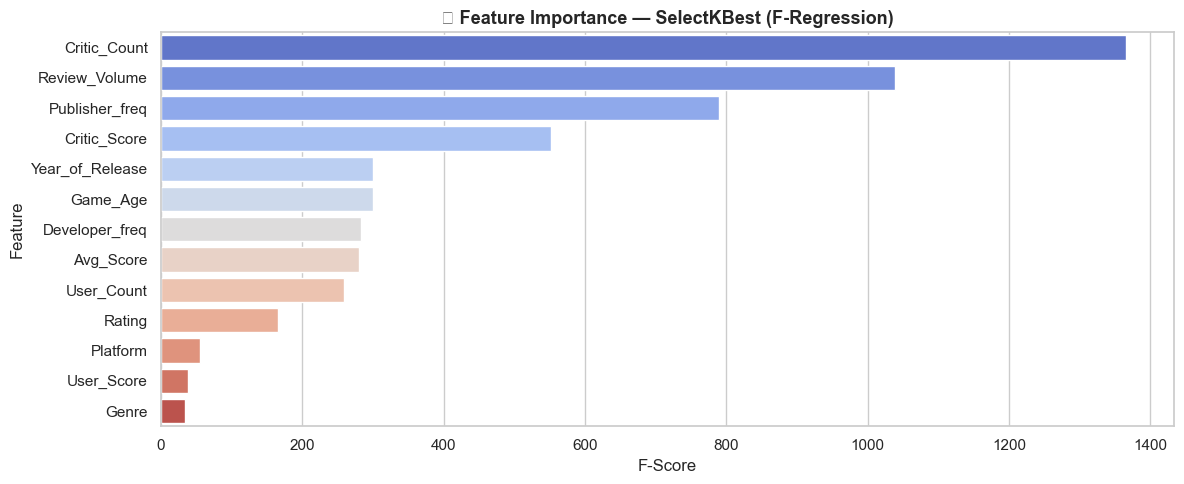


   ✅ Selected 13 significant features (p < 0.05):
   ['Critic_Count', 'Review_Volume', 'Publisher_freq', 'Critic_Score', 'Year_of_Release', 'Game_Age', 'Developer_freq', 'Avg_Score', 'User_Count', 'Rating', 'Platform', 'User_Score', 'Genre']

📏 5E: Feature Scaling — StandardScaler
   (Fit on X_train only → transform both train and test)
   ✅ Scaling applied | Mean ≈ 0, Std ≈ 1 for all features
   ✅ X_train_scaled shape: (12535, 13)
   ✅ X_test_scaled  shape: (3134, 13)

────────────────────────────────────────────────────────────
  ✅ DATA PREPROCESSING COMPLETE — Summary
────────────────────────────────────────────────────────────
  5A │ Feature Engineering  → Added 3 new features
  5B │ Frequency Encoding   → Publisher, Developer
  5C │ Label Encoding       → Platform, Genre, Rating
  5D │ Feature Selection    → SelectKBest (F-Regression, p < 0.05)
     │ Features kept: 13
  5E │ StandardScaler       → Fit on train, transform train & test
─────────────────────────────────────────────

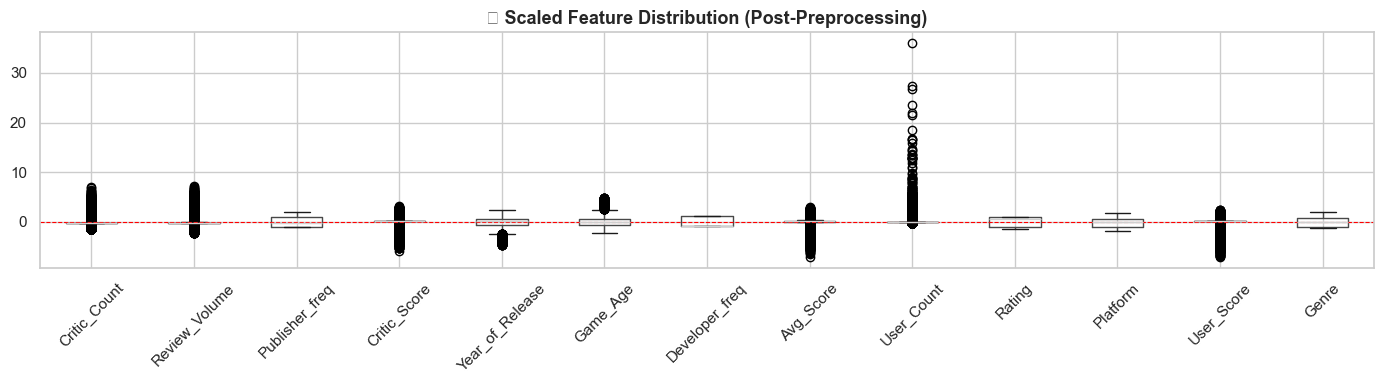


  🤖 Linear Regression
  MAE            : 0.1515
  RMSE           : 0.2031
  R² (Test)      : 0.2022
  CV R² (5-Fold) : 0.2192 ± 0.0110

  🤖 Ridge Regression
  MAE            : 0.1515
  RMSE           : 0.2031
  R² (Test)      : 0.2022
  CV R² (5-Fold) : 0.2192 ± 0.0110

  🤖 Decision Tree
  MAE            : 0.1354
  RMSE           : 0.1916
  R² (Test)      : 0.2900
  CV R² (5-Fold) : 0.2910 ± 0.0297

  🤖 Random Forest
  MAE            : 0.1251
  RMSE           : 0.1759
  R² (Test)      : 0.4013
  CV R² (5-Fold) : 0.3890 ± 0.0190

  🤖 XGBoost
  MAE            : 0.1199
  RMSE           : 0.1710
  R² (Test)      : 0.4344
  CV R² (5-Fold) : 0.4351 ± 0.0090


📊 ALL MODELS — COMPARISON TABLE
            Model   MAE  RMSE    R²  CV R²  CV Std
          XGBoost 0.120 0.171 0.434  0.435   0.009
    Random Forest 0.125 0.176 0.401  0.389   0.019
    Decision Tree 0.135 0.192 0.290  0.291   0.030
 Ridge Regression 0.151 0.203 0.202  0.219   0.011
Linear Regression 0.151 0.203 0.202  0.219   0.011

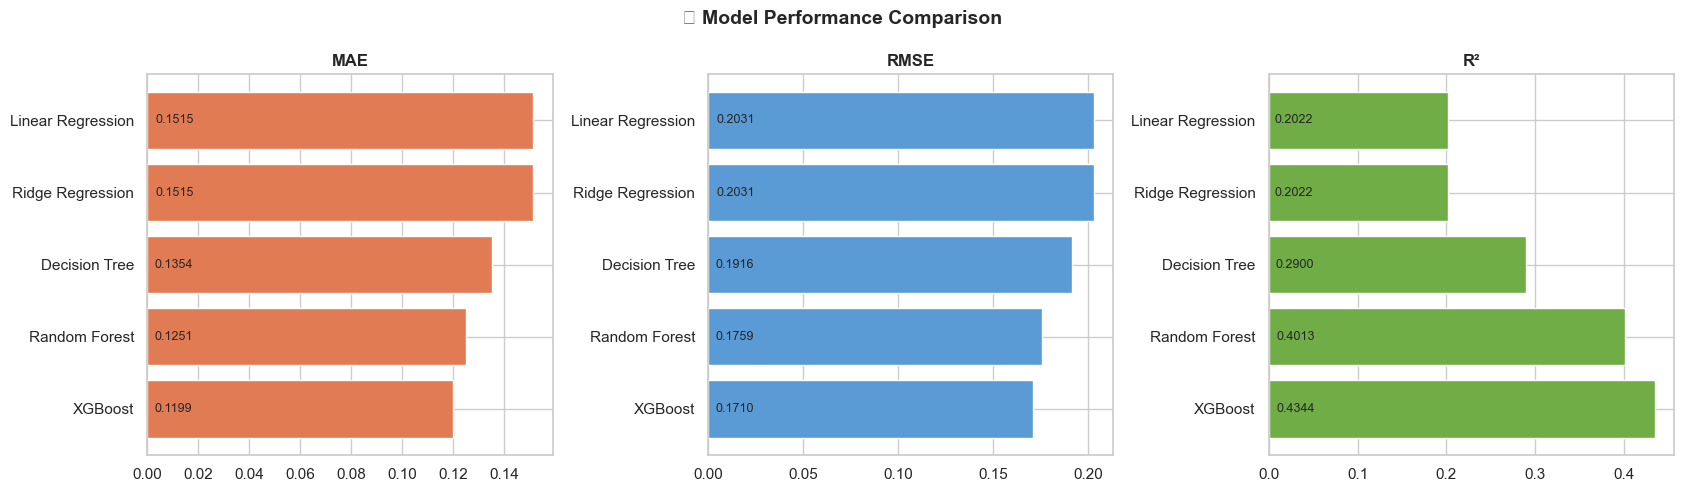

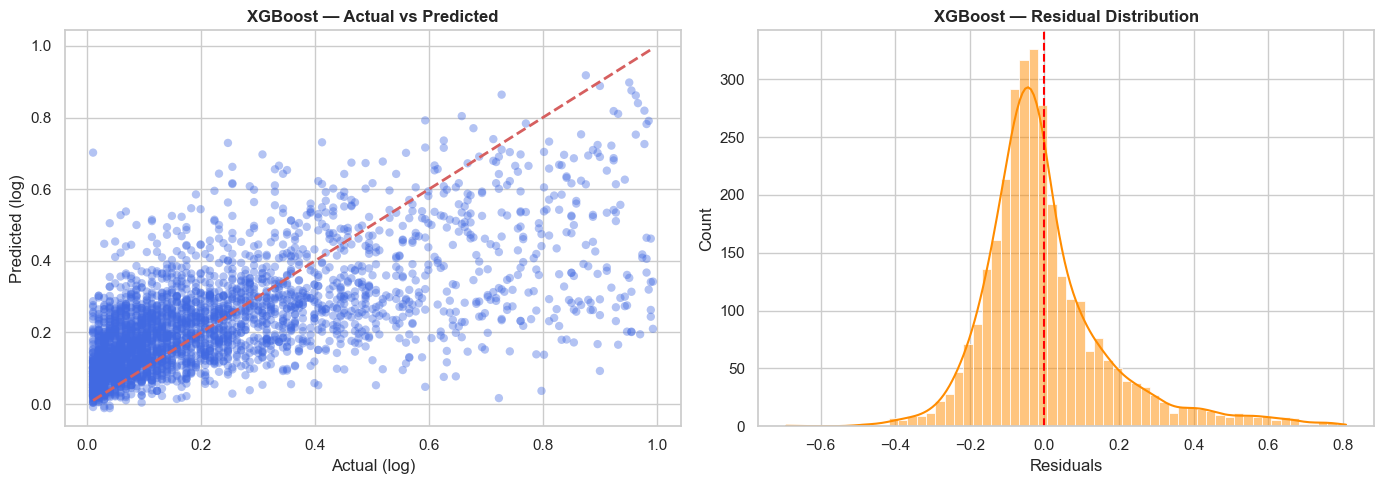

⚙️  Hyperparameter Tuning — XGBoost (RandomizedSearchCV, 50 iterations)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best Parameters:
   subsample: 0.8
   reg_lambda: 2
   reg_alpha: 0
   n_estimators: 200
   min_child_weight: 3
   max_depth: 8
   learning_rate: 0.05
   gamma: 0
   colsample_bytree: 0.6

   Best CV R²: 0.4518

  🚀 TUNED XGBoost — Final Test Performance
  MAE  : 0.1173
  RMSE : 0.1681
  R²   : 0.4532

  📈 R² Change: 0.4344 → 0.4532  (Δ +0.0188)


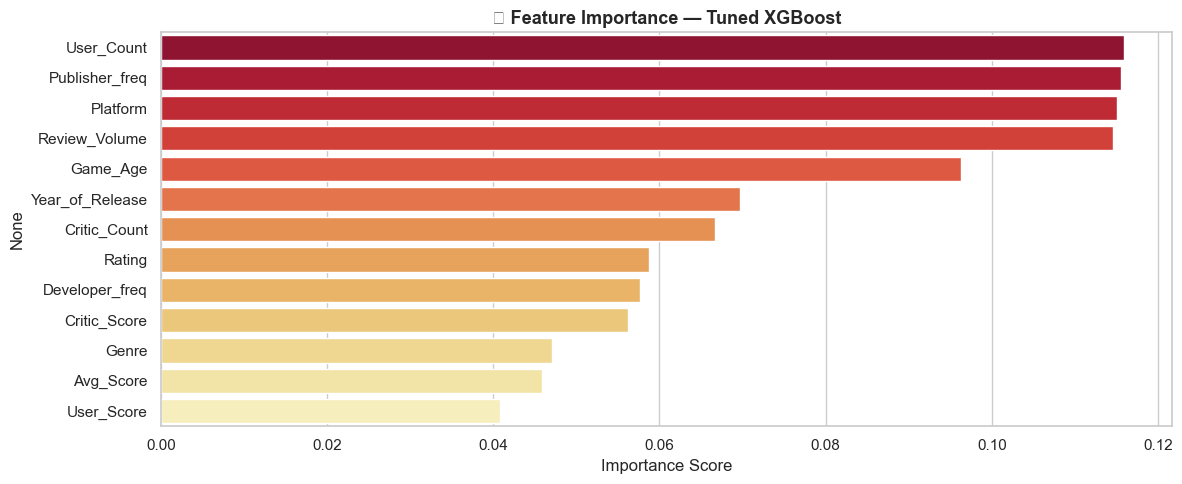


📊 Before vs After Tuning:
Metric  Before Tuning  After Tuning
   MAE          0.120         0.117
  RMSE          0.171         0.168
    R²          0.434         0.453


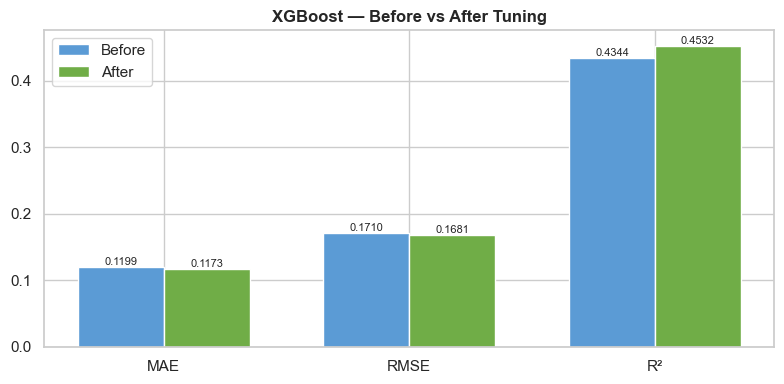


🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯
   FINAL PIPELINE SUMMARY
🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

  1. Data Reading     → 16719 rows × 16 cols loaded
  2. Data Cleaning    → 15669 rows after cleaning
  3. EDA              → 7 visualizations generated
  4. Data Split       → 80% train / 20% test
  5. Preprocessing    → Engineered 3 features, Encoded 5 cols,
                         Selected 13 features, Scaled all
  6. Model Evaluation → 5 models trained and compared
  7. Tuning           → XGBoost tuned with RandomizedSearchCV (50 iter)

  🏆 Best Model : Tuned XGBoost
  📊 R²         : 0.4532
  📉 MAE        : 0.1173
  📉 RMSE       : 0.1681

  Top Features : ['User_Count', 'Publisher_freq', 'Platform']

✅ All plots saved. Pipeline complete!


In [1]:
# ============================================================
#  VIDEO GAME GLOBAL SALES PREDICTION — REGRESSION ANALYSIS
#  Target Variable: Global_Sales
#
#  PIPELINE ORDER:
#  1. Data Reading & Understanding
#  2. Data Cleaning
#  3. EDA
#  4. Data Split
#  5. Data Preprocessing      ← clearly separate step
#  6. Model Building & Evaluation
#  7. Model Tuning & Evaluation
# ============================================================


# ─────────────────────────────────────────────────────────────
# CELL 1 — INSTALL & IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────
# Uncomment the line below if running for the first time:
# !pip install scikit-learn xgboost pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ All Libraries Imported Successfully")


# ════════════════════════════════════════════════════════════
# STEP 1 — DATA READING & UNDERSTANDING
# ════════════════════════════════════════════════════════════

# ── CELL 2: Load Dataset ──
df = pd.read_csv("C:/Users/MOHAMED NAVEETH/OneDrive/Documents/aml assignment/video game dataset.csv")
print("✅ Dataset Loaded")
print(f"   Shape : {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

# ── CELL 3: Dataset Info ──
print("=" * 60)
print("📋 DATASET INFORMATION")
print("=" * 60)
df.info()

# ── CELL 4: Statistical Summary ──
print("\n📊 Statistical Summary — Numeric Columns")
df.describe()

# ── CELL 5: Categorical Column Summary ──
print("\n📋 Categorical Column Unique Value Counts")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"  🔹 {col}: {df[col].nunique()} unique values | Top → {df[col].value_counts().index[0]}")

# ── CELL 6: Missing Value Analysis ──
print("\n🔍 Missing Values Analysis")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# Plot missing values
plt.figure(figsize=(12, 4))
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
sns.barplot(x=cols_with_missing.index, y=cols_with_missing['Missing %'], palette='Reds_r')
plt.title('Missing Value % per Column', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Missing %')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()

# ── CELL 7: Target Variable Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Global_Sales'].dropna(), bins=100, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Global Sales — Raw (Skewed)', fontweight='bold')
axes[0].set_xlabel('Global Sales (Millions)')

sns.histplot(np.log1p(df['Global_Sales'].dropna()), bins=80, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Global Sales — Log Transformed (More Normal)', fontweight='bold')
axes[1].set_xlabel('log(Global Sales + 1)')

plt.suptitle('🎯 Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

print(f"\n📌 Skewness (Raw): {df['Global_Sales'].skew():.3f}")
print(f"📌 Skewness (Log): {np.log1p(df['Global_Sales'].dropna()).skew():.3f}")
print("   → Log-transform is JUSTIFIED because skewness > 1")


# ════════════════════════════════════════════════════════════
# STEP 2 — DATA CLEANING
# ════════════════════════════════════════════════════════════

# ── CELL 8: Copy Original DataFrame ──
df_clean = df.copy()

# ── CELL 9: Drop Rows Where Target is Missing ──
before = len(df_clean)
df_clean.dropna(subset=['Global_Sales'], inplace=True)
print(f"🗑️  Dropped {before - len(df_clean)} rows with missing Global_Sales")
print(f"   Remaining rows: {len(df_clean)}")

# ── CELL 10: Fix User_Score ('tbd' → NaN → float) ──
df_clean['User_Score'] = df_clean['User_Score'].replace('tbd', np.nan)
df_clean['User_Score'] = pd.to_numeric(df_clean['User_Score'], errors='coerce')
print("\n✅ User_Score: 'tbd' replaced with NaN and converted to float")

# ── CELL 11: Fix Year_of_Release (to numeric, remove unrealistic years) ──
df_clean['Year_of_Release'] = pd.to_numeric(df_clean['Year_of_Release'], errors='coerce')
before = len(df_clean)
df_clean = df_clean[(df_clean['Year_of_Release'] >= 1980) | (df_clean['Year_of_Release'].isna())]
print(f"✅ Year_of_Release cleaned | Invalid years removed: {before - len(df_clean)}")
print(f"   Valid range: {int(df_clean['Year_of_Release'].min())} – {int(df_clean['Year_of_Release'].max())}")

# ── CELL 12: Remove Outliers in Global_Sales (IQR Method) ──
Q1 = df_clean['Global_Sales'].quantile(0.25)
Q3 = df_clean['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3 * IQR    # Using 3×IQR (less aggressive than 1.5×)
before = len(df_clean)
df_clean = df_clean[df_clean['Global_Sales'] <= upper]
print(f"\n✅ Outlier Removal | Upper bound = {upper:.2f}M")
print(f"   Removed {before - len(df_clean)} outlier rows | Remaining: {len(df_clean)}")

# ── CELL 13: Fill Missing Values in Numeric Columns (Median) ──
print("\n📥 Filling Missing Numeric Values with Median:")
num_fill_cols = ['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Year_of_Release']
for col in num_fill_cols:
    med = df_clean[col].median()
    df_clean[col].fillna(med, inplace=True)
    print(f"   ✅ {col} → median = {med}")

# ── CELL 14: Fill Missing Values in Categorical Columns ('Unknown') ──
print("\n📥 Filling Missing Categorical Values with 'Unknown':")
cat_fill_cols = ['Genre', 'Publisher', 'Developer', 'Rating', 'Platform']
for col in cat_fill_cols:
    df_clean[col].fillna('Unknown', inplace=True)
    print(f"   ✅ {col} → 'Unknown'")

# ── CELL 15: Verify No Missing Values Remain ──
remaining_nulls = df_clean.isnull().sum().sum()
print(f"\n✅ Total Remaining Missing Values: {remaining_nulls}")
print(f"✅ Clean Dataset Shape: {df_clean.shape}")


# ════════════════════════════════════════════════════════════
# STEP 3 — EXPLORATORY DATA ANALYSIS (EDA)
# ════════════════════════════════════════════════════════════

# ── CELL 16: Correlation Heatmap ──
plt.figure(figsize=(12, 7))
num_df = df_clean.select_dtypes(include=np.number)
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 9})
plt.title('📊 Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("\n💡 Key Observations:")
print("   - NA_Sales, EU_Sales have strong positive correlation with Global_Sales")
print("   - Critic_Score has moderate correlation with Global_Sales")
print("   - These regional sales will be DROPPED later to avoid data leakage")

# ── CELL 17: Average Global Sales by Genre ──
genre_sales = df_clean.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(13, 5))
sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='viridis')
plt.title('🎮 Average Global Sales by Genre', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Avg Global Sales (Millions)')
plt.tight_layout()
plt.savefig('sales_by_genre.png', dpi=150)
plt.show()

# ── CELL 18: Total Sales by Platform (Top 15) ──
platform_sales = df_clean.groupby('Platform')['Global_Sales'].sum().nlargest(15)
plt.figure(figsize=(13, 5))
sns.barplot(x=platform_sales.index, y=platform_sales.values, palette='plasma')
plt.title('🕹️ Total Global Sales by Platform (Top 15)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total Global Sales (Millions)')
plt.tight_layout()
plt.savefig('sales_by_platform.png', dpi=150)
plt.show()

# ── CELL 19: Sales Trend Over Years ──
yearly = df_clean.groupby('Year_of_Release')['Global_Sales'].sum()
plt.figure(figsize=(13, 5))
plt.plot(yearly.index, yearly.values, marker='o', lw=2, color='darkorange')
plt.fill_between(yearly.index, yearly.values, alpha=0.15, color='darkorange')
plt.title('📅 Total Global Sales by Year of Release', fontsize=13, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Total Global Sales (Millions)')
plt.tight_layout()
plt.savefig('sales_by_year.png', dpi=150)
plt.show()

# ── CELL 20: Critic Score & User Score vs Global Sales ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df_clean['Critic_Score'], df_clean['Global_Sales'],
                alpha=0.3, color='royalblue', edgecolors='none')
axes[0].set_title('Critic Score vs Global Sales', fontweight='bold')
axes[0].set_xlabel('Critic Score'); axes[0].set_ylabel('Global Sales')

axes[1].scatter(df_clean['User_Score'], df_clean['Global_Sales'],
                alpha=0.3, color='tomato', edgecolors='none')
axes[1].set_title('User Score vs Global Sales', fontweight='bold')
axes[1].set_xlabel('User Score')

plt.suptitle('📈 Score Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scores_vs_sales.png', dpi=150)
plt.show()

# ── CELL 21: Regional Sales Breakdown ──
region_totals = df_clean[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
plt.figure(figsize=(6, 5))
plt.pie(region_totals, labels=['North America','Europe','Japan','Other'],
        autopct='%1.1f%%', startangle=140,
        colors=['#4e79a7','#f28e2b','#e15759','#76b7b2'])
plt.title('🌍 Regional Sales Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regional_sales.png', dpi=150)
plt.show()

# ── CELL 22: ESRB Rating vs Global Sales ──
rating_order = df_clean.groupby('Rating')['Global_Sales'].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.boxplot(x='Rating', y='Global_Sales', data=df_clean, order=rating_order, palette='Set2')
plt.title('🎯 Global Sales by ESRB Rating', fontsize=13, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('sales_by_rating.png', dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# STEP 4 — DATA SPLIT
# (Split BEFORE preprocessing to prevent data leakage)
# ════════════════════════════════════════════════════════════

# ── CELL 23: Prepare features — Drop leakage & irrelevant columns ──
df_model = df_clean.copy()

# Drop: Name (text ID), regional sales (data leakage — sub-components of target)
drop_cols = ['Name', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
df_model.drop(columns=drop_cols, inplace=True)
print(f"🗑️  Dropped columns to prevent data leakage: {drop_cols}")

# ── CELL 24: Define Target — Log-transform Global_Sales ──
# Log-transform JUSTIFIED: raw skewness was > 1 (confirmed in Step 1)
df_model['Global_Sales_log'] = np.log1p(df_model['Global_Sales'])
df_model.drop(columns=['Global_Sales'], inplace=True)

X = df_model.drop(columns=['Global_Sales_log'])
y = df_model['Global_Sales_log']

print(f"\n✅ Features (X) shape : {X.shape}")
print(f"✅ Target  (y) shape  : {y.shape}")
print(f"📋 Feature Columns    : {list(X.columns)}")

# ── CELL 25: Train-Test Split (80% / 20%) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n✅ Train Set : {X_train.shape[0]} rows")
print(f"✅ Test  Set : {X_test.shape[0]} rows")
print("   NOTE: All preprocessing will be fit ONLY on X_train to avoid data leakage")


# ════════════════════════════════════════════════════════════
# STEP 5 — DATA PREPROCESSING
# (Applied AFTER split to prevent leakage)
# ════════════════════════════════════════════════════════════

print("\n" + "═"*60)
print("  STEP 5 — DATA PREPROCESSING")
print("═"*60)

# ── CELL 26: 5A — Feature Engineering (New Columns) ──
print("\n📐 5A: Feature Engineering")

def add_features(df):
    df = df.copy()
    # Combined quality score (Critic scaled to 0-10, averaged with User)
    df['Avg_Score'] = (df['Critic_Score'] / 10 + df['User_Score']) / 2
    # Review popularity: log of total review volume
    df['Review_Volume'] = np.log1p(df['Critic_Count'] + df['User_Count'])
    # Game age in years
    df['Game_Age'] = 2024 - df['Year_of_Release']
    return df

X_train = add_features(X_train)
X_test  = add_features(X_test)

print("   ✅ Avg_Score     → average of Critic + User score (0–10 scale)")
print("   ✅ Review_Volume → log(Critic_Count + User_Count) — measures popularity")
print("   ✅ Game_Age      → 2024 - Year_of_Release — how old the game is")

# ── CELL 27: 5B — Encode High-Cardinality Columns (Frequency Encoding) ──
print("\n🔤 5B: Frequency Encoding — Publisher & Developer")
print("   (Too many unique values for Label Encoding → use frequency instead)")

high_card_cols = ['Publisher', 'Developer']
freq_maps = {}  # Store maps fitted on train only

for col in high_card_cols:
    freq_map = X_train[col].value_counts() / len(X_train)   # fit on train
    freq_maps[col] = freq_map
    X_train[col + '_freq'] = X_train[col].map(freq_map).fillna(0)
    X_test[col  + '_freq'] = X_test[col].map(freq_map).fillna(0)  # apply same map
    X_train.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)
    print(f"   ✅ {col} → Frequency Encoded")

# ── CELL 28: 5C — Label Encode Low-Cardinality Columns ──
print("\n🏷️ 5C: Label Encoding — Platform, Genre, Rating")

le_encoders = {}
label_enc_cols = ['Platform', 'Genre', 'Rating']

for col in label_enc_cols:
    le = LabelEncoder()
    le.fit(X_train[col].astype(str))        # fit on train only
    X_train[col] = le.transform(X_train[col].astype(str))
    # Handle unseen labels in test set
    X_test[col] = X_test[col].astype(str).apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    le_encoders[col] = le
    print(f"   ✅ {col} → Label Encoded ({le.classes_[:3]}...)")

# ── CELL 29: 5D — Feature Selection (SelectKBest) ──
print("\n📊 5D: Feature Selection using SelectKBest (F-Regression)")

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature' : X_train.columns,
    'F-Score' : selector.scores_,
    'P-Value' : selector.pvalues_
}).sort_values('F-Score', ascending=False)

print("\n   Feature Rankings:")
print(feature_scores.to_string(index=False))

# Visualise feature scores
plt.figure(figsize=(12, 5))
sns.barplot(x='F-Score', y='Feature', data=feature_scores, palette='coolwarm')
plt.title('📊 Feature Importance — SelectKBest (F-Regression)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_selection.png', dpi=150)
plt.show()

# Keep only statistically significant features (p-value < 0.05)
selected_features = feature_scores[feature_scores['P-Value'] < 0.05]['Feature'].tolist()
print(f"\n   ✅ Selected {len(selected_features)} significant features (p < 0.05):")
print(f"   {selected_features}")

X_train = X_train[selected_features]
X_test  = X_test[selected_features]

# ── CELL 30: 5E — Feature Scaling (StandardScaler) ──
print("\n📏 5E: Feature Scaling — StandardScaler")
print("   (Fit on X_train only → transform both train and test)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform ONLY on test

print(f"   ✅ Scaling applied | Mean ≈ 0, Std ≈ 1 for all features")
print(f"   ✅ X_train_scaled shape: {X_train_scaled.shape}")
print(f"   ✅ X_test_scaled  shape: {X_test_scaled.shape}")

# ── CELL 31: Preprocessing Summary ──
print("\n" + "─"*60)
print("  ✅ DATA PREPROCESSING COMPLETE — Summary")
print("─"*60)
print("  5A │ Feature Engineering  → Added 3 new features")
print("  5B │ Frequency Encoding   → Publisher, Developer")
print("  5C │ Label Encoding       → Platform, Genre, Rating")
print("  5D │ Feature Selection    → SelectKBest (F-Regression, p < 0.05)")
print(f"     │ Features kept: {len(selected_features)}")
print("  5E │ StandardScaler       → Fit on train, transform train & test")
print("─"*60)

# Visualise preprocessed training features (scaled)
plt.figure(figsize=(14, 4))
pd.DataFrame(X_train_scaled, columns=selected_features).boxplot(rot=45)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.title('📦 Scaled Feature Distribution (Post-Preprocessing)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scaled_features.png', dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# STEP 6 — MODEL BUILDING & EVALUATION (5 Models)
# ════════════════════════════════════════════════════════════

# ── CELL 32: Evaluation Helper Function ──
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')
    print(f"\n{'='*55}")
    print(f"  🤖 {name}")
    print(f"{'='*55}")
    print(f"  MAE            : {mae:.4f}")
    print(f"  RMSE           : {rmse:.4f}")
    print(f"  R² (Test)      : {r2:.4f}")
    print(f"  CV R² (5-Fold) : {cv.mean():.4f} ± {cv.std():.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse,
            'R²': r2, 'CV R²': cv.mean(), 'CV Std': cv.std(), 'y_pred': y_pred}

# ── CELL 33: Train All 5 Models ──
all_results = []
all_predictions = {}

# Model 1 — Linear Regression
r1 = evaluate_model("Linear Regression",
                     LinearRegression(),
                     X_train_scaled, X_test_scaled, y_train, y_test)
all_results.append(r1); all_predictions['Linear Regression'] = r1['y_pred']

# Model 2 — Ridge Regression
r2 = evaluate_model("Ridge Regression",
                     Ridge(alpha=1.0),
                     X_train_scaled, X_test_scaled, y_train, y_test)
all_results.append(r2); all_predictions['Ridge Regression'] = r2['y_pred']

# Model 3 — Decision Tree
r3 = evaluate_model("Decision Tree",
                     DecisionTreeRegressor(max_depth=8, random_state=42),
                     X_train_scaled, X_test_scaled, y_train, y_test)
all_results.append(r3); all_predictions['Decision Tree'] = r3['y_pred']

# Model 4 — Random Forest
r4 = evaluate_model("Random Forest",
                     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
                     X_train_scaled, X_test_scaled, y_train, y_test)
all_results.append(r4); all_predictions['Random Forest'] = r4['y_pred']

# Model 5 — XGBoost
r5 = evaluate_model("XGBoost",
                     XGBRegressor(n_estimators=300, learning_rate=0.05,
                                  max_depth=6, random_state=42,
                                  verbosity=0, n_jobs=-1),
                     X_train_scaled, X_test_scaled, y_train, y_test)
all_results.append(r5); all_predictions['XGBoost'] = r5['y_pred']

# ── CELL 34: Model Comparison Table ──
results_df = pd.DataFrame(all_results).drop(columns=['y_pred'])
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)
print("\n\n📊 ALL MODELS — COMPARISON TABLE")
print(results_df.to_string(index=False))

# ── CELL 35: Visual Comparison ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric, color, ascending in zip(
    axes, ['MAE','RMSE','R²'], ['#e07b54','#5b9bd5','#70ad47'], [True, True, False]
):
    s = results_df.sort_values(metric, ascending=ascending)
    ax.barh(s['Model'], s[metric], color=color, edgecolor='white')
    ax.set_title(f'{metric}', fontweight='bold', fontsize=12)
    for i, v in enumerate(s[metric]):
        ax.text(v * 0.01 + ax.get_xlim()[1] * 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('🏆 Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# ── CELL 36: Actual vs Predicted — Best Model ──
best_name = results_df.iloc[0]['Model']
best_preds = all_predictions[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, best_preds, alpha=0.4, color='royalblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual (log)'); axes[0].set_ylabel('Predicted (log)')
axes[0].set_title(f'{best_name} — Actual vs Predicted', fontweight='bold')

residuals = y_test - best_preds
sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residuals')
axes[1].set_title(f'{best_name} — Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# STEP 7 — MODEL TUNING & EVALUATION (Best Model: XGBoost)
# ════════════════════════════════════════════════════════════

# ── CELL 37: RandomizedSearchCV Hyperparameter Tuning ──
print("⚙️  Hyperparameter Tuning — XGBoost (RandomizedSearchCV, 50 iterations)")

param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 4, 5, 6, 7, 8],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1, 0.15],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2, 0.3],
    'reg_alpha'       : [0, 0.01, 0.1, 1],
    'reg_lambda'      : [1, 1.5, 2, 5],
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50, cv=5, scoring='r2',
    random_state=42, verbose=1, n_jobs=-1
)
random_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best Parameters:")
for k, v in random_search.best_params_.items():
    print(f"   {k}: {v}")
print(f"\n   Best CV R²: {random_search.best_score_:.4f}")

# ── CELL 38: Evaluate Tuned Model ──
best_xgb    = random_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test_scaled)

mae_t  = mean_absolute_error(y_test, y_pred_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_t   = r2_score(y_test, y_pred_tuned)

print("\n" + "="*55)
print("  🚀 TUNED XGBoost — Final Test Performance")
print("="*55)
print(f"  MAE  : {mae_t:.4f}")
print(f"  RMSE : {rmse_t:.4f}")
print(f"  R²   : {r2_t:.4f}")
print(f"\n  📈 R² Change: {r5['R²']:.4f} → {r2_t:.4f}  (Δ {r2_t - r5['R²']:+.4f})")

# ── CELL 39: Feature Importance from Tuned XGBoost ──
feat_imp = pd.Series(best_xgb.feature_importances_, index=selected_features)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='YlOrRd_r')
plt.title('🌟 Feature Importance — Tuned XGBoost', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_tuned.png', dpi=150)
plt.show()

# ── CELL 40: Before vs After Tuning ──
compare = pd.DataFrame({
    'Metric'        : ['MAE', 'RMSE', 'R²'],
    'Before Tuning' : [r5['MAE'], r5['RMSE'], r5['R²']],
    'After Tuning'  : [mae_t, rmse_t, r2_t]
})
print("\n📊 Before vs After Tuning:")
print(compare.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3); w = 0.35
b1 = ax.bar(x - w/2, compare['Before Tuning'], w, label='Before', color='#5b9bd5')
b2 = ax.bar(x + w/2, compare['After Tuning'],  w, label='After',  color='#70ad47')
ax.set_xticks(x); ax.set_xticklabels(['MAE', 'RMSE', 'R²'])
ax.legend(); ax.set_title('XGBoost — Before vs After Tuning', fontweight='bold')
for b in [*b1, *b2]:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
            f'{b.get_height():.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('tuning_comparison.png', dpi=150)
plt.show()

# ── CELL 41: FINAL SUMMARY ──
print("\n" + "🎯"*30)
print("   FINAL PIPELINE SUMMARY")
print("🎯"*30)
print(f"\n  1. Data Reading     → {df.shape[0]} rows × {df.shape[1]} cols loaded")
print(f"  2. Data Cleaning    → {df_clean.shape[0]} rows after cleaning")
print(f"  3. EDA              → 7 visualizations generated")
print(f"  4. Data Split       → 80% train / 20% test")
print(f"  5. Preprocessing    → Engineered 3 features, Encoded 5 cols,")
print(f"                         Selected {len(selected_features)} features, Scaled all")
print(f"  6. Model Evaluation → 5 models trained and compared")
print(f"  7. Tuning           → XGBoost tuned with RandomizedSearchCV (50 iter)")
print(f"\n  🏆 Best Model : Tuned XGBoost")
print(f"  📊 R²         : {r2_t:.4f}")
print(f"  📉 MAE        : {mae_t:.4f}")
print(f"  📉 RMSE       : {rmse_t:.4f}")
print(f"\n  Top Features : {feat_imp.head(3).index.tolist()}")
print("\n✅ All plots saved. Pipeline complete!")